In [ ]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise RuntimeError("Could not locate project root (no .git found above cwd)")

PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "mlp" / "experience_replay"


# MLP Experience Replay
Train an MLPClassifier with year-wise incremental scaling and experience replay.

In [ ]:
import copy
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm

from src.mlp_replay.data import (
    load_dataset_and_splits,
    prepare_raw_features_for_year,
    prepare_features_for_year,
    precompute_yearly_raw_cache,
)
from src.mlp_replay.model import (
    build_mlp_model,
    capture_model_state,
    restore_model_state,
)
from src.mlp_replay.checkpointing import (
    create_empty_training_history,
    load_all_training_histories,
    save_all_training_histories,
    load_completion_status,
    save_completion_status,
    append_training_log,
    format_ratio_key,
    get_cached_raw_year,
)

warnings.filterwarnings('ignore')

## 1. Load Data and Splits

In [ ]:
ds_path = PROJECT_ROOT / 'training_data_with_features_plus_monthly_indices.zarr'
split_path = PROJECT_ROOT / 'data_split.npz'
ds, train_pixel_indices, val_pixel_indices, test_pixel_indices = load_dataset_and_splits(ds_path, split_path)


## 2. Feature Engineering

`prepare_raw_features_for_year` and `prepare_features_for_year` now live in `src/mlp_replay/data.py` and are imported above.


## 3. Initialize Class Weights and MLP

In [ ]:
print('Precomputing raw yearly features for train/validation splits...')
n_years = len(ds.year)


train_feature_cache = precompute_yearly_raw_cache(ds, train_pixel_indices, n_years, 'train')
val_feature_cache = precompute_yearly_raw_cache(ds, val_pixel_indices, n_years, 'validation')

print('Computing class weights from cached training labels...')
train_label_batches = [y_batch for _, y_batch in train_feature_cache.values() if len(y_batch) > 0]
if not train_label_batches:
    raise ValueError('No valid training labels after filtering.')

all_train_labels = np.concatenate(train_label_batches).astype(int)
all_train_labels = all_train_labels[np.isin(all_train_labels, [0, 1])]
if len(all_train_labels) == 0:
    raise ValueError('No valid training labels after filtering.')

classes = np.array([0, 1])
class_weights_array = compute_class_weight('balanced', classes=classes, y=all_train_labels)
class_weight_dict = {classes[i]: class_weights_array[i] for i in range(len(classes))}

print('Class weights:')
print(f"  Class 0: {class_weight_dict[0]:.4f}")
print(f"  Class 1: {class_weight_dict[1]:.4f}")

model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    alpha=0.0001,
    random_state=42,
    solver='adam',
    learning_rate='adaptive',
    max_iter=1,
    learning_rate_init=0.001,
    warm_start=False,
    verbose=False,
)
print('MLP initialized')

## 4. Replay-Enabled Online Training

In [ ]:
import json
from datetime import datetime

REPLAY_RATIOS = [0.2, 0.3, 0.4, 0.5]
REPLAY_ENABLED = True
REPLAY_RANDOM_STATE = 42

CHUNK_SIZE = 50000
MAX_EPOCHS = 15
PATIENCE = 3
MIN_DELTA = 0.0005

CHECKPOINT_DIR = EXPERIMENTS_DIR / 'training_checkpoints_mlp_experience_replay_opt_fix'
ALL_HISTORIES_FILE = CHECKPOINT_DIR / 'mlp_replay_all_training_histories.pkl'
COMPLETION_STATUS_FILE = CHECKPOINT_DIR / 'mlp_replay_completion_status.json'
TRAINING_LOG_FILE = CHECKPOINT_DIR / 'mlp_replay_training_log.txt'
COMBINED_HISTORY_FILENAME = 'mlp_classifier_history_prevyears_monthly_features_incremental_scaler_experience_replay_all_ratios_opt_fix.csv'

CHECKPOINT_DIR.mkdir(exist_ok=True)

if 'train_feature_cache' not in globals() or 'val_feature_cache' not in globals():
    raise ValueError('Raw feature caches not found. Run Cell 8 first to precompute yearly features.')

all_training_histories = load_all_training_histories(ALL_HISTORIES_FILE)
completion_status = load_completion_status(COMPLETION_STATUS_FILE)

n_years = len(ds.year)
year_values = ds.year.values
year_value_to_idx = {int(y): idx for idx, y in enumerate(year_values)}
all_target_year_values = [int(year_values[idx]) for idx in range(1, n_years)]

print(f'Checkpoint directory: {CHECKPOINT_DIR.resolve()}')
print(f'Replay ratios: {REPLAY_RATIOS}')
append_training_log(TRAINING_LOG_FILE, f'Started training run for ratios: {REPLAY_RATIOS}')

for ratio_idx, replay_ratio in enumerate(REPLAY_RATIOS):
    ratio_key = format_ratio_key(replay_ratio)
    output_suffix = f'incremental_scaler_experience_replay_{ratio_key}_opt_fix'
    models_dir_name = f'models_mlp_prevyears_monthly_features_{output_suffix}'
    scaler_file_template = f'scaler_year_{{year}}_mlp_prevyears_monthly_features_{output_suffix}.pkl'
    model_file_template = f'model_year_{{year}}_mlp_prevyears_monthly_features_{output_suffix}.pkl'
    final_scaler_filename = f'scaler_final_mlp_prevyears_monthly_features_{output_suffix}.pkl'
    final_model_filename = f'mlp_classifier_model_prevyears_monthly_features_{output_suffix}.pkl'
    history_filename = f'mlp_classifier_history_prevyears_monthly_features_{output_suffix}.csv'

    models_dir = EXPERIMENTS_DIR / models_dir_name
    models_dir.mkdir(exist_ok=True)

    if ratio_key in completion_status.get('completed_ratios', []):
        print(f'[{ratio_key}] already completed. Skipping ratio.')
        append_training_log(TRAINING_LOG_FILE, f'[{ratio_key}] skipped (already completed).')
        continue

    training_history = all_training_histories.get(ratio_key, create_empty_training_history())
    for key in create_empty_training_history().keys():
        training_history.setdefault(key, [])

    completed_years = set(int(y) for y in completion_status.get('completed_years', {}).get(ratio_key, []))
    completed_years.update(int(y) for y in training_history.get('year', []))
    completion_status.setdefault('completed_years', {})[ratio_key] = sorted(list(completed_years))

    replay_rng = np.random.default_rng(REPLAY_RANDOM_STATE + ratio_idx)

    model = None
    incremental_scaler = None
    start_year_idx = 1

    if completed_years:
        resume_candidate_years = sorted(completed_years, reverse=True)
        resumed = False
        for resume_year in resume_candidate_years:
            year_model_path = models_dir / model_file_template.format(year=resume_year)
            year_scaler_path = models_dir / scaler_file_template.format(year=resume_year)
            if year_model_path.exists() and year_scaler_path.exists() and resume_year in year_value_to_idx:
                with open(year_model_path, 'rb') as f:
                    model = pickle.load(f)
                with open(year_scaler_path, 'rb') as f:
                    incremental_scaler = pickle.load(f)
                start_year_idx = year_value_to_idx[resume_year] + 1
                resumed = True
                print(f'[{ratio_key}] resuming from year {resume_year}; continuing at index {start_year_idx}.')
                append_training_log(TRAINING_LOG_FILE, f'[{ratio_key}] resumed from year {resume_year}.')
                break

        if resumed:
            # Clean up completed_years and training_history for years after the resumed year
            completed_years = {y for y in completed_years if y <= resume_year}
            if training_history.get('year'):
                keep_indices = [i for i, y in enumerate(training_history['year']) if y <= resume_year]
                for key in training_history.keys():
                    if isinstance(training_history[key], list):
                        training_history[key] = [training_history[key][i] for i in keep_indices]
        else:
            print(f'[{ratio_key}] checkpoint artifacts missing/inconsistent. Restarting this ratio from scratch.')
            append_training_log(TRAINING_LOG_FILE, f'[{ratio_key}] restart due to missing/inconsistent checkpoint artifacts.')
            completed_years = set()
            completion_status['completed_years'][ratio_key] = []
            training_history = create_empty_training_history()

    if model is None:
        model = build_mlp_model()
    if incremental_scaler is None:
        incremental_scaler = StandardScaler()

    print(f'[{ratio_key}] Model output directory: {models_dir.resolve()}')
    print(f'[{ratio_key}] Years to train: 1..{n_years - 1} (year 0 skipped)')

    for year_idx in tqdm(range(start_year_idx, n_years), desc=f'{ratio_key} by year'):
        year_val = int(year_values[year_idx])

        if year_val in completed_years:
            continue

        X_train_raw, y_train_batch = get_cached_raw_year(train_feature_cache, year_idx)
        X_val_raw, y_val_batch = get_cached_raw_year(val_feature_cache, year_idx)

        if len(X_train_raw) == 0 or len(X_val_raw) == 0:
            print(f'[{ratio_key}] Year {year_val}: skipped (empty after filtering)')
            completed_years.add(year_val)
            completion_status['completed_years'][ratio_key] = sorted(list(completed_years))
            save_completion_status(COMPLETION_STATUS_FILE, completion_status)
            append_training_log(TRAINING_LOG_FILE, f'[{ratio_key}] year {year_val} skipped (empty after filtering).')
            continue

        incremental_scaler.partial_fit(X_train_raw)
        X_train_batch = incremental_scaler.transform(X_train_raw)
        X_val_batch = incremental_scaler.transform(X_val_raw)

        scaler_checkpoint = copy.deepcopy(incremental_scaler)
        year_scaler_path = models_dir / scaler_file_template.format(year=year_val)
        with open(year_scaler_path, 'wb') as f:
            pickle.dump(scaler_checkpoint, f)

        n_samples = len(X_train_batch)
        replay_target_size = int(n_samples * replay_ratio) if REPLAY_ENABLED else 0

        replay_X_parts = []
        replay_y_parts = []
        if REPLAY_ENABLED and year_idx > 1:
            for past_year_idx in range(1, year_idx):
                X_past_raw, y_past = get_cached_raw_year(train_feature_cache, past_year_idx)
                if len(X_past_raw) > 0:
                    X_past = incremental_scaler.transform(X_past_raw)
                    replay_X_parts.append(X_past)
                    replay_y_parts.append(y_past)

        if replay_X_parts:
            X_replay_pool = np.vstack(replay_X_parts)
            y_replay_pool = np.concatenate(replay_y_parts)
        else:
            X_replay_pool = np.empty((0, X_train_batch.shape[1]), dtype=X_train_batch.dtype)
            y_replay_pool = np.empty((0,), dtype=y_train_batch.dtype)

        replay_pool_size = len(y_replay_pool)
        replay_used_size = min(replay_target_size, replay_pool_size) if REPLAY_ENABLED else 0

        if hasattr(model, 'n_features_in_') and int(model.n_features_in_) != int(X_train_batch.shape[1]):
            raise ValueError(
                f'Feature count mismatch at year {year_val}: model expects {model.n_features_in_}, got {X_train_batch.shape[1]}'
            )

        best_val_pr_auc = -np.inf
        patience_counter = 0
        best_model_state = None

        for epoch in range(MAX_EPOCHS):
            if replay_used_size > 0:
                replay_indices = replay_rng.choice(replay_pool_size, size=replay_used_size, replace=False)
                X_replay_sampled = X_replay_pool[replay_indices]
                y_replay_sampled = y_replay_pool[replay_indices]
                X_combined = np.concatenate([X_train_batch, X_replay_sampled], axis=0)
                y_combined = np.concatenate([y_train_batch, y_replay_sampled], axis=0)
            else:
                X_combined = X_train_batch
                y_combined = y_train_batch

            combined_n_samples = len(X_combined)
            shuffle_idx = replay_rng.permutation(combined_n_samples)
            X_train_shuffled = X_combined[shuffle_idx]
            y_train_shuffled = y_combined[shuffle_idx]
            n_chunks = max(1, int(np.ceil(combined_n_samples / CHUNK_SIZE)))

            for chunk_idx in range(n_chunks):
                start_idx = chunk_idx * CHUNK_SIZE
                end_idx = min(start_idx + CHUNK_SIZE, combined_n_samples)
                X_chunk = X_train_shuffled[start_idx:end_idx]
                y_chunk = y_train_shuffled[start_idx:end_idx]
                sample_weights_chunk = np.array([class_weight_dict[int(label)] for label in y_chunk])
                model.partial_fit(X_chunk, y_chunk, classes=classes, sample_weight=sample_weights_chunk)

            y_val_pred = model.predict(X_val_batch)
            y_val_proba = model.predict_proba(X_val_batch)[:, 1]
            val_pr_auc = average_precision_score(y_val_batch, y_val_proba) if len(np.unique(y_val_batch)) > 1 else np.nan

            if val_pr_auc > best_val_pr_auc + MIN_DELTA:
                best_val_pr_auc = val_pr_auc
                patience_counter = 0
                best_model_state = capture_model_state(model)
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break

        if best_model_state is not None:
            restore_model_state(model, best_model_state)

        y_train_pred = model.predict(X_train_batch)
        y_val_pred = model.predict(X_val_batch)
        y_val_proba = model.predict_proba(X_val_batch)[:, 1]

        train_acc = accuracy_score(y_train_batch, y_train_pred)
        train_prec = precision_score(y_train_batch, y_train_pred, zero_division=0)
        train_rec = recall_score(y_train_batch, y_train_pred, zero_division=0)
        train_f1 = f1_score(y_train_batch, y_train_pred, zero_division=0)

        val_acc = accuracy_score(y_val_batch, y_val_pred)
        val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)
        val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)
        val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)
        if len(np.unique(y_val_batch)) > 1:
            val_roc_auc = roc_auc_score(y_val_batch, y_val_proba)
            val_pr_auc = average_precision_score(y_val_batch, y_val_proba)
        else:
            val_roc_auc = np.nan
            val_pr_auc = np.nan

        training_history['year'].append(year_val)
        training_history['train_accuracy'].append(train_acc)
        training_history['train_precision'].append(train_prec)
        training_history['train_recall'].append(train_rec)
        training_history['train_f1'].append(train_f1)
        training_history['val_accuracy'].append(val_acc)
        training_history['val_precision'].append(val_prec)
        training_history['val_recall'].append(val_rec)
        training_history['val_f1'].append(val_f1)
        training_history['val_roc_auc'].append(val_roc_auc)
        training_history['val_pr_auc'].append(val_pr_auc)
        training_history['replay_pool_size'].append(int(replay_pool_size))
        training_history['replay_target_size'].append(int(replay_target_size))
        training_history['replay_used_size'].append(int(replay_used_size))

        year_model_path = models_dir / model_file_template.format(year=year_val)
        with open(year_model_path, 'wb') as f:
            pickle.dump(model, f)

        completed_years.add(year_val)
        completion_status['completed_years'][ratio_key] = sorted(list(completed_years))
        all_training_histories[ratio_key] = training_history.copy()
        save_all_training_histories(ALL_HISTORIES_FILE, all_training_histories)
        save_completion_status(COMPLETION_STATUS_FILE, completion_status)

        print(
            f'[{ratio_key}] Year {year_val}: Train F1={train_f1:.3f}, Val F1={val_f1:.3f}, Val PR-AUC={val_pr_auc:.3f}, '
            f'replay_used={replay_used_size:,}/{replay_pool_size:,}'
        )
        append_training_log(
            TRAINING_LOG_FILE,
            f'[{ratio_key}] completed year {year_val} with replay_used={replay_used_size}/{replay_pool_size}.',
        )

    if hasattr(incremental_scaler, 'mean_'):
        final_scaler_path = models_dir / final_scaler_filename
        with open(final_scaler_path, 'wb') as f:
            pickle.dump(incremental_scaler, f)
        print(f'[{ratio_key}] Final incremental scaler saved: {final_scaler_path.name}')

    final_model_path = models_dir / final_model_filename
    with open(final_model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'[{ratio_key}] Final model saved: {final_model_path.name}')

    ratio_history_df = pd.DataFrame(training_history).sort_values('year').reset_index(drop=True)
    ratio_history_path = models_dir / history_filename
    ratio_history_df.to_csv(ratio_history_path, index=False)
    print(f'[{ratio_key}] History saved: {ratio_history_path}')

    if set(all_target_year_values).issubset(completed_years):
        if ratio_key not in completion_status.get('completed_ratios', []):
            completion_status.setdefault('completed_ratios', []).append(ratio_key)
        save_completion_status(COMPLETION_STATUS_FILE, completion_status)
        append_training_log(TRAINING_LOG_FILE, f'[{ratio_key}] marked as fully completed.')

    all_training_histories[ratio_key] = training_history.copy()
    save_all_training_histories(ALL_HISTORIES_FILE, all_training_histories)

combined_history_frames = []
for ratio_key, history_dict in all_training_histories.items():
    if not isinstance(history_dict, dict):
        continue
    if len(history_dict.get('year', [])) == 0:
        continue
    df_ratio = pd.DataFrame(history_dict).sort_values('year').reset_index(drop=True)
    replay_ratio = float(ratio_key.split('_')[1])
    df_ratio['ratio_key'] = ratio_key
    df_ratio['replay_ratio'] = replay_ratio
    combined_history_frames.append(df_ratio)

if combined_history_frames:
    combined_history_df = pd.concat(combined_history_frames, ignore_index=True)
    combined_history_df = combined_history_df.sort_values(['replay_ratio', 'year']).reset_index(drop=True)
    combined_history_path = EXPERIMENTS_DIR / COMBINED_HISTORY_FILENAME
    combined_history_df.to_csv(combined_history_path, index=False)
    print(f'Combined history saved: {combined_history_path}')
    print(f'Combined rows: {len(combined_history_df):,}')
else:
    print('No history data available to write combined history.')

save_completion_status(COMPLETION_STATUS_FILE, completion_status)
save_all_training_histories(ALL_HISTORIES_FILE, all_training_histories)
append_training_log(TRAINING_LOG_FILE, 'Training run completed.')

## 5. Save Training History

In [6]:
import json

CHECKPOINT_DIR = EXPERIMENTS_DIR / 'training_checkpoints_mlp_experience_replay_opt_fix'
ALL_HISTORIES_FILE = CHECKPOINT_DIR / 'mlp_replay_all_training_histories.pkl'
COMPLETION_STATUS_FILE = CHECKPOINT_DIR / 'mlp_replay_completion_status.json'
COMBINED_HISTORY_FILENAME = 'mlp_classifier_history_prevyears_monthly_features_incremental_scaler_experience_replay_all_ratios_opt_fix.csv'

if ALL_HISTORIES_FILE.exists():
    with open(ALL_HISTORIES_FILE, 'rb') as f:
        all_training_histories = pickle.load(f)
else:
    all_training_histories = {}

if COMPLETION_STATUS_FILE.exists():
    with open(COMPLETION_STATUS_FILE, 'r', encoding='utf-8') as f:
        completion_status = json.load(f)
else:
    completion_status = {'completed_ratios': [], 'completed_years': {}}

summary_rows = []
for ratio_key in sorted(all_training_histories.keys()):
    history_dict = all_training_histories[ratio_key]
    n_rows = len(history_dict.get('year', []))
    last_year = history_dict['year'][-1] if n_rows > 0 else np.nan
    last_val_f1 = history_dict['val_f1'][-1] if n_rows > 0 else np.nan
    last_val_pr_auc = history_dict['val_pr_auc'][-1] if n_rows > 0 else np.nan
    is_completed = ratio_key in completion_status.get('completed_ratios', [])
    summary_rows.append(
        {
            'ratio_key': ratio_key,
            'rows': n_rows,
            'last_year': last_year,
            'last_val_f1': last_val_f1,
            'last_val_pr_auc': last_val_pr_auc,
            'completed': is_completed,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values('ratio_key').reset_index(drop=True)
print('Per-ratio training summary:')
display(summary_df)

combined_history_path = EXPERIMENTS_DIR / COMBINED_HISTORY_FILENAME
if combined_history_path.exists():
    combined_df = pd.read_csv(combined_history_path)
    print(f'Combined history file: {combined_history_path}')
    print(f'Rows: {len(combined_df):,}')
    display(combined_df.tail())
else:
    print(f'Combined history file not found: {combined_history_path}')

Per-ratio training summary:


,ratio_key,rows,last_year,last_val_f1,last_val_pr_auc,completed
0,RR_0.2,6,2022,0.200146,0.351389,True
1,RR_0.3,6,2022,0.188999,0.345946,True
2,RR_0.4,6,2022,0.202404,0.350416,True
3,RR_0.5,6,2022,0.199093,0.348812,True


Combined history file: mlp_classifier_history_prevyears_monthly_features_incremental_scaler_experience_replay_all_ratios_opt_fix.csv
Rows: 24


,year,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc,replay_pool_size,replay_target_size,replay_used_size,ratio_key,replay_ratio
19,2018,0.894061,0.136776,0.782769,0.232863,0.889106,0.135054,0.741839,0.228507,0.902206,0.430870,5575648,2793403,2793403,RR_0.5,0.5
20,2019,0.892113,0.131868,0.774992,0.225386,0.897338,0.122705,0.750678,0.210931,0.904641,0.431813,11162455,2793385,2793385,RR_0.5,0.5
21,2020,0.884766,0.117554,0.797002,0.204888,0.883506,0.102082,0.754950,0.179846,0.905569,0.466873,16749226,2793696,2793696,RR_0.5,0.5
22,2021,0.910663,0.121066,0.777804,0.209520,0.904673,0.114303,0.758875,0.198681,0.905984,0.439977,22336618,2793427,2793427,RR_0.5,0.5
23,2022,0.823171,0.130448,0.841799,0.225891,0.819094,0.114110,0.779998,0.199093,0.882394,0.348812,27923473,2796040,2796040,RR_0.5,0.5


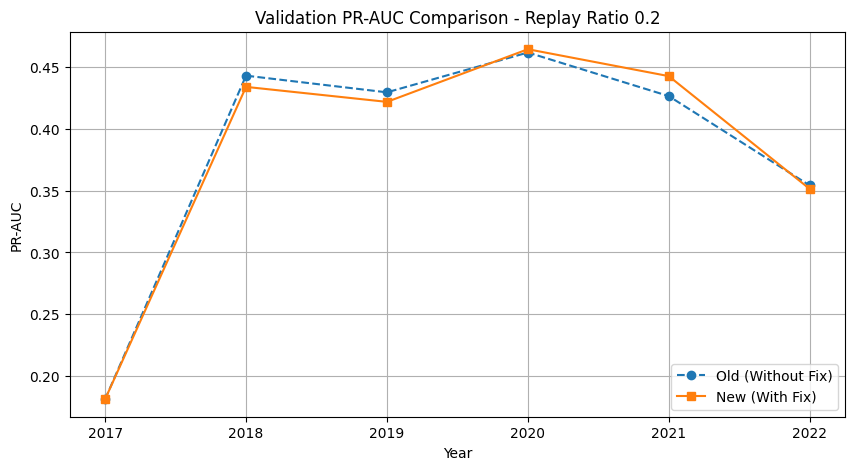

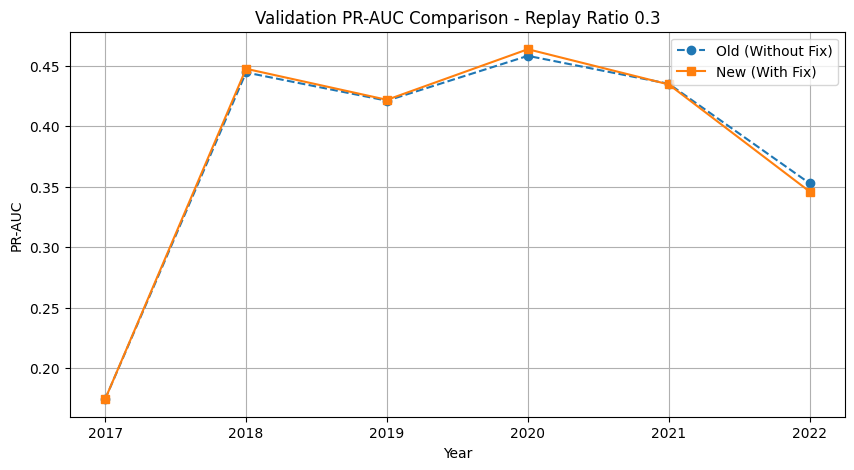

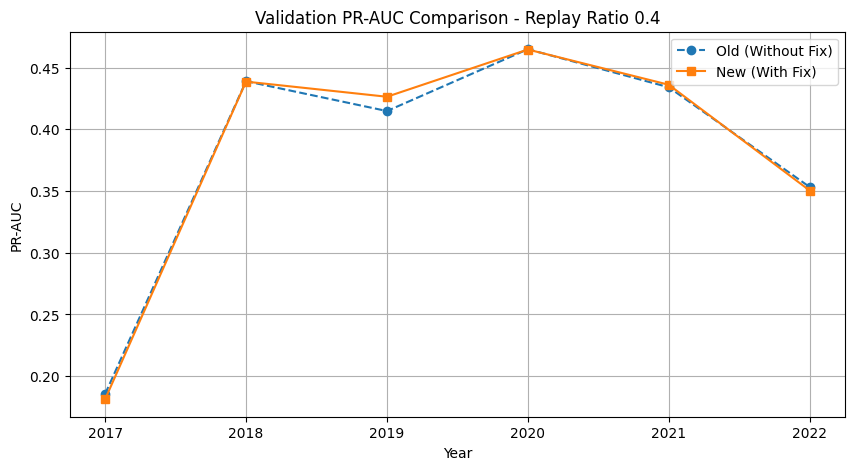

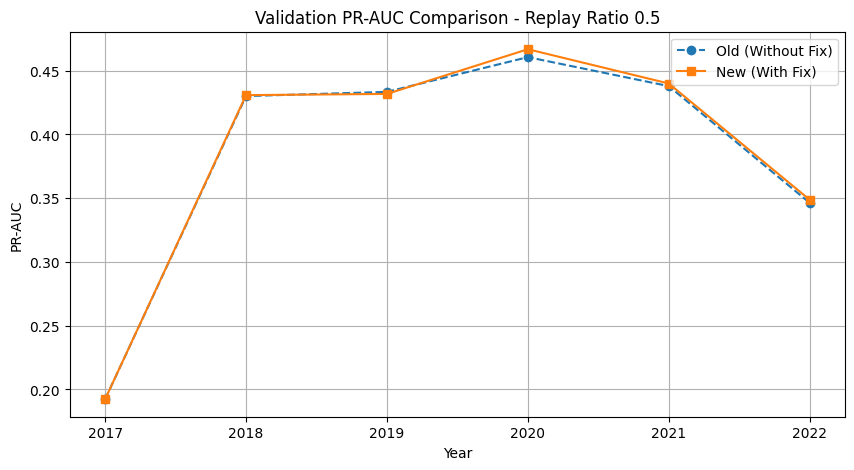


=== Performance Comparison Summary ===
 Replay Ratio  Year  Val PR-AUC (Old)  Val PR-AUC (New)  PR-AUC Diff  Val F1 (Old)  Val F1 (New)   F1 Diff
          0.2  2017          0.181250          0.181288     0.000037      0.141446      0.134192 -0.007254
          0.2  2018          0.442999          0.433917    -0.009081      0.205422      0.188348 -0.017074
          0.2  2019          0.429509          0.421791    -0.007718      0.202682      0.175919 -0.026763
          0.2  2020          0.461724          0.464385     0.002662      0.186618      0.181235 -0.005383
          0.2  2021          0.426466          0.442623     0.016157      0.198694      0.209361  0.010667
          0.2  2022          0.354174          0.351389    -0.002785      0.208943      0.200146 -0.008797
          0.3  2017          0.174481          0.174481     0.000000      0.126864      0.126864  0.000000
          0.3  2018          0.444292          0.447330     0.003038      0.214485      0.212140 -0.0023

In [7]:
## 6. Performance Comparison (Old vs. New Optimizer State Rollback)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ratios = [0.2, 0.3, 0.4, 0.5]
comparison_data = []

for ratio in ratios:
    old_path = EXPERIMENTS_DIR / f'models_mlp_prevyears_monthly_features_incremental_scaler_experience_replay_RR_{ratio}' / f'mlp_classifier_history_prevyears_monthly_features_incremental_scaler_experience_replay_RR_{ratio}.csv'
    new_path = EXPERIMENTS_DIR / f'models_mlp_prevyears_monthly_features_incremental_scaler_experience_replay_RR_{ratio}_opt_fix' / f'mlp_classifier_history_prevyears_monthly_features_incremental_scaler_experience_replay_RR_{ratio}_opt_fix.csv'
    
    if old_path.exists() and new_path.exists():
        df_old = pd.read_csv(old_path)
        df_new = pd.read_csv(new_path)
        
        df_merge = pd.merge(df_old, df_new, on='year', suffixes=('_old', '_new'))
        
        for _, row in df_merge.iterrows():
            comparison_data.append({
                'Replay Ratio': ratio,
                'Year': int(row['year']),
                'Val PR-AUC (Old)': row['val_pr_auc_old'],
                'Val PR-AUC (New)': row['val_pr_auc_new'],
                'PR-AUC Diff': row['val_pr_auc_new'] - row['val_pr_auc_old'],
                'Val F1 (Old)': row['val_f1_old'],
                'Val F1 (New)': row['val_f1_new'],
                'F1 Diff': row['val_f1_new'] - row['val_f1_old']
            })
            
        # Generate plot
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(df_merge['year'], df_merge['val_pr_auc_old'], marker='o', linestyle='--', label='Old (Without Fix)')
        ax.plot(df_merge['year'], df_merge['val_pr_auc_new'], marker='s', linestyle='-', label='New (With Fix)')
        ax.set_title(f'Validation PR-AUC Comparison - Replay Ratio {ratio}')
        ax.set_xlabel('Year')
        ax.set_ylabel('PR-AUC')
        ax.grid(True)
        ax.legend()
        plt.savefig(EXPERIMENTS_DIR / f'pr_auc_comparison_RR_{ratio}.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'Missing histories for ratio {ratio}. Old exists: {old_path.exists()}, New exists: {new_path.exists()}')

if comparison_data:
    df_comp = pd.DataFrame(comparison_data)
    print('\n=== Performance Comparison Summary ===')
    print(df_comp.to_string(index=False))
    df_comp.to_csv(EXPERIMENTS_DIR / 'optimizer_fix_comparison_results.csv', index=False)
else:
    print('No comparison data generated.')
